# 2 - It's totally normal! If the Sample Fits.

# Import Function

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helper Functions

In [2]:
def norm(x):
    """Returns the p=2 norm."""
    return np.sqrt(np.square(x).sum())


def augment_matrix(A, y):
    """Augments matrix A and vector y."""
    if A.shape[0] != y.shape[0]:
        raise ValueError(f'{A.shape[0]} not matching {y.shape[0]}')
    
    return np.c_[A, y].astype(np.float64)

def _ero1(A, i1, i2, verbose=True):
    """Performs elementary row operation I."""
    print(f'ERO1: R{i1} <-> R{i2}') if verbose else None
    A_ = A.copy()
    A_[[i1, i2]] = A_[[i2, i1]]
    return A_

def _ero2(A, i, k, verbose=True):
    """Performs elementary row operation II."""
    print(f'ERO2: R{i} <- {k} x R{i}') if verbose else None
    A_ = A.copy()
    A_[i] = k * A_[i]
    return A_

def _ero3(A, i1, i2, k, verbose=True):
    """Performs elementary row operation III."""
    print(f'ERO3: R{i1} <- R{i1} + {k} x R{i2}') if verbose else None
    A_ = A.copy()
    A_[i1] = A_[i1] + A_[i2] * k
    return A_

def rref(A, verbose=False, display_round=4):
    """Transforms augmented matrix A to its Reduced Row Echelon Form."""
    A_ = A.copy()
    rows = A.shape[0]

    for i in range(rows):

        if verbose:
            print(f'\nRow {i} (FROM)')
            print(np.round(A_, display_round))

        imax = np.argmax(np.abs(A_[i:, i]))+i
        A_ = _ero1(A_, i, imax, verbose)
        if A_[i, i] == 0:
            continue
        A_ = _ero2(A_, i, 1/A_[i, i], verbose)
        A_[i, i] = 1.0

        for j in range(rows):
            if j != i:
                k = A_[j, i]
                if k != 0:
                    A_ = _ero3(A_, j, i, -k, verbose)
        if verbose:
            print(f'Row {i} (TO)')
            print(np.round(A_, display_round))

    return A_

def inverse(A):
    """Solves for the inverse of A by solving for the RRF of the augmented A
    and an identity matrix."""
    cutoff = A.shape[0]
    eye = np.eye(cutoff)
    A_eye = augment_matrix(A, eye)
    inverse = rref(A_eye)[:, cutoff:]
    return inverse

def solve_sle(A, b):
    """Solves the x in the Ax = b problem."""
    Ab = augment_matrix(A, b)
    Ab_rref = rref(Ab)
    return Ab_rref[:, -1]

def generate_samples(mu, sigma, N):
    np.random.seed(42)
    return mu + sigma * np.random.randn(N)

def simpsons_13_rule(y, h):
    n = len(y) - 1
    if n % 2 == 0:
        print('Performing composite Simpson\'s 1/3 rule')
        result = y[0] + y[-1] + 4 * np.sum(y[1:n:2]) + 2 * np.sum(y[2:n-1:2])
        return result * h/3
    else:
        print('Performing composite Simpson\'s 1/3 rule with Simpson\'s 3/8 rule')
        n1 = n - 3
        y1 = y[:n1 + 1] # for simpson's 1/3
        y2 = y[n1:] # for simpson's 3/8

        # simpson's 1/3
        result_13 = (y1[0] + y1[-1] + 4 * np.sum(y1[1:-1:2]) + 2 * np.sum(y1[2:-1:2])) * h/3
        result_38 = (y2[0] + 3 * y2[1] + 3 * y2[2] + y2[3]) * 3 * h / 8
        return result_13 + result_38
    
def model(x, a, b, c):
    return a * np.exp(-b * (x - c)**2)

def jacobian(x, a, b, c):
    J_a = model(x, 1, b, c)
    J_b = - (x - c)**2 * model(x, a, b, c)
    J_c = 2 * b * (x - c) * model(x, a, b, c)
    return np.stack((J_a, J_b, J_c), axis=1)

def nonlinear_least_squares_fit(x, y, tol=1e-6, max_iter=1000):
    """Using Gauss-Newton to solve for the weights"""
    theta = np.zeros(3)
    for _ in range(max_iter):
        j = jacobian(x, *theta)
        r = model(x, *theta) - y
        adjust = inverse(j.T @ j) @ j.T @ r
        theta -= adjust

        if norm(theta) <= tol:
            break
    
    return theta

In [3]:
def analyze_random_points(N, mu=0, sigma=1, bin_size=0.5):
    mu=0
    sigma=1
    bin_size=0.5
    x = generate_samples(mu, sigma, N)
    bin_edges = np.arange(mu - 6*sigma, mu + 6*sigma + bin_size, bin_size)
    hist, _ = np.histogram(x, bins=bin_edges, density=False)
    area = simpsons_13_rule(hist, bin_size)
    print(f'For N = {N}, histogram area = {area:.3f}')
    hist_normalized = hist/area
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_edges, hist_normalized, bin_centers

# Discussion of the Problem

For the problem, we generate $N$ number of points and put them within bins where bin size is 0.5. The histogram spans from -6 to 6, thus, we have 25 bins in total. The objective here is to show what happens to the histograms as we increase the count of points stored in the bins.

The law of large nummbers states that if we increase the number of points for a given distribution, then those numbers will approach the true distribution of its population. For example, if we sample a few points, say 10, from a normally distributed population, then the distribution of the small sample size might not be normally distributed. However, as we increase the number of points in the sample, then the sample will converge to the true distribution. Hence, we will attempt to show this by trying 4 values of N, namely 10, 100, 1000, and 10000. The N=10 is added here for us to appreciate the effect of increasing N.

# Normal Distribution

We say that $x \sim N(\mu, \sigma)$ if the probability density function (PDF) follows:
$$
\text{pdf}(x) = f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp{ \left(-\frac{(x-\mu)^2}{2 \sigma^2} \right)}
$$

For the specific case of a standard normal distribution where the data is zero centered and unit variance $x \sim N(0, 1)$
$$
\text{pdf}(x) = f(x; 0, 1) = \frac{1}{\sqrt{2 \pi}} \exp{ \left(-\frac{x^2}{2} \right)}
$$

We will create points using numpy's method $np.random.randn(N)$ to generate normal noise. These generated noise points are then multiplied to $\sigma^2=1$ and added to $mu=0$. This transformation is valid and is still normal, regardless of what the mean and variance is.
Once the data is now generated, they are stored within bins of size 0.5. Since we preselected to have the range from -6 to 6, we have 25 bins, from $[-6, -5.5), [-5.5, -5.0), ..., [5.0, 5.5), [5.5, 6]$. Let's say our random data is 2.38, then it will be stored in the $[2.0, 2.5)$ bin. Now that we have stored all our data in the histogram bins, the height of the histograms are integers. While this gives us a functional value to understand the distribution of the data, this is not a valid probability density function PDF. PDFs should have a definite integral or sum of 1 within the interval $(-\inf, \inf)$. This is because PDFs define the probability or chance of getting that number from a population. While PDFs doesn't directly give us a probability (unlike Probability Mass Functions), given a closed interval, we are able to determine a probability e.g., ~38 percent probability of drawing a sample from $[-0.5, 0.5]$.

Therefore, we must solve for the area of the histograms and perform element division such that the sum is now 1.0. This step is the normalization part. To perform this, we utilize Composite Simpson's 1/3 Rule as this is believed to have acceptable cost and accuracy.


# Simpson's Rule
To perform Simpson's 1/3 Rule, we utilize this formula:
$$
I = \int_{x_0}^{x_n} f(x) dx = h \left( \frac{f(x_0) + 4\Sigma_{i=1, odd}^{n-1} f(x_i) + 4\Sigma_{j=2, even}^{n-2} f(x_j) + f(x_n)}{3} \right)
$$
Here, h is the step size. However, one condition here is that number of steps must be even. But for our case since we have 24 points and 23 steps, this method is unusable. Therefore, what we do is perform Composite Simpson's 1/3 rule for the first 21 points and then Simpson's 3/8 rule for the last 4 points.

$$
I = \int_{x_n}^{x_{n-3}} f(x) dx = 3h \left( \frac{f(x_{n-3}) + 3f(x_{n-2}) + 3f(x_{n-1}) + f(x_n)}{8} \right)
$$

# Nonlinear Least Squares Regression 
For this model, we assume that our function is of the form shown below. This form is used as this is also the form of the normal distribution pdf but with arbitrary coefficients.

$$
f(x; a, b, c) = a \exp(-b (x - c)^2)
$$

We start with an initial guess for parameters $w=[a, b, c]$ then perform Gauss-Newton to optimize the best values for $w$ such that $\frac{1}{2}r^T r$ is minimized. Note here that $r=f(x) - y$.
The parameters is solved using:
$$
w_{k+1} = w_{k} - [J_r^T(w_k) J_r(w_k)] ^ {-1} J_r^T(w_k) r(w_k)
$$

Our stopping tolerance here is either 1000 max iterations or if the norm of $r$ is less than 1e-6.

Performing composite Simpson's 1/3 rule with Simpson's 3/8 rule
For N = 10, histogram area = 6.333
Equivalent equation for N = 10: f(x) = 0.397 * exp(-0.795 * (x-0.276)^2)


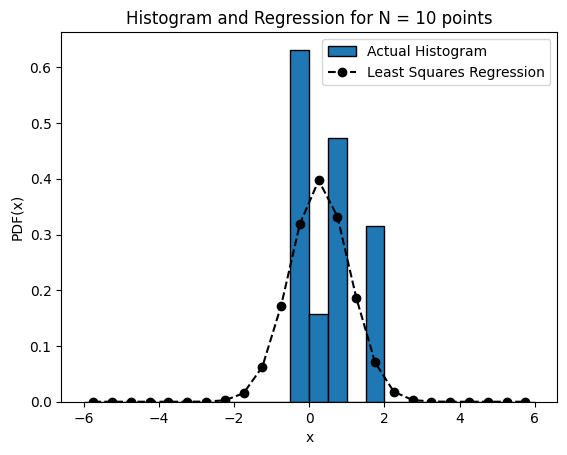

Performing composite Simpson's 1/3 rule with Simpson's 3/8 rule
For N = 100, histogram area = 50.667
Equivalent equation for N = 100: f(x) = 0.439 * exp(-0.633 * (x+0.089)^2)


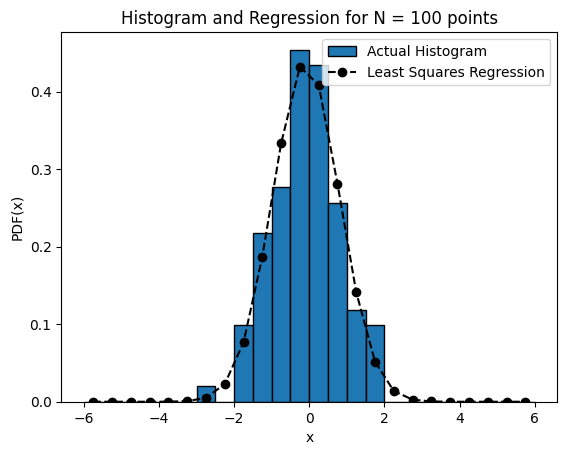

Performing composite Simpson's 1/3 rule with Simpson's 3/8 rule
For N = 1000, histogram area = 496.333
Equivalent equation for N = 1000: f(x) = 0.403 * exp(-0.504 * (x+0.008)^2)


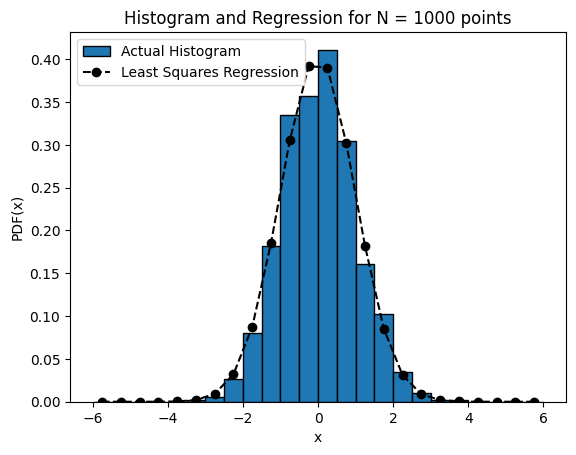

Performing composite Simpson's 1/3 rule with Simpson's 3/8 rule
For N = 10000, histogram area = 4987.000
Equivalent equation for N = 10000: f(x) = 0.396 * exp(-0.492 * (x+0.004)^2)


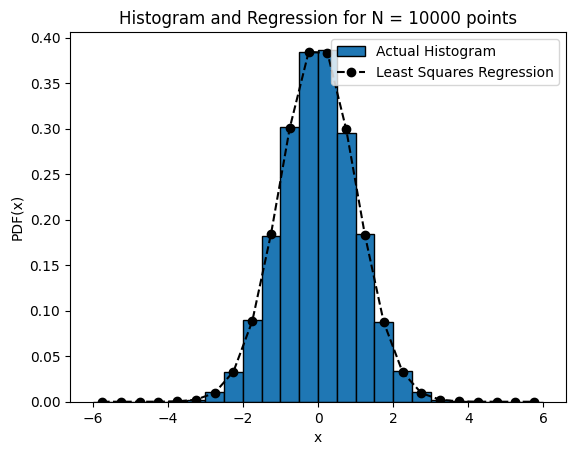

In [4]:
for N in [10, 100, 1000, 10_000]:
    bin_edges, hist_normalized, bin_centers = analyze_random_points(N)
    w = nonlinear_least_squares_fit(bin_centers, hist_normalized)
    a, b, c = w
    print(f'Equivalent equation for N = {N}: f(x) = {a:.3f} * exp({"-" if b >= 0 else ""}{np.abs(b):.3f} * (x{"+" if c <= 0 else "-"}{np.abs(c):.3f})^2)')

    plt.hist(bin_edges[:-1], bin_edges, weights=hist_normalized, edgecolor='black', label='Actual Histogram')
    plt.plot(bin_centers, model(bin_centers, *w), 'k--o', label='Least Squares Regression')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('PDF(x)')
    plt.title(f'Histogram and Regression for N = {N} points')
    plt.show();

To appreciate the effect of Law of Large numbers more, we also considered the N=10. As shown from the histogram alone, we can see the N=10 poorly replicates the population distribution. However starting from N=100 up to N=10000, we can already see that the histograms already look normal. We can also see from the results of the least squares regression that the points closely follows the histograms. Therefore, as N approaches infinity, the distribution truly follows its population distribution.

In [5]:
a = 1/np.sqrt(2*np.pi*1)
b = 1/2
c = 0

print('The actual equation representing the probability density function is:')
print(f'pdf(x) = {a:.3f} * exp({"-" if b >= 0 else ""}{np.abs(b):.3f} * (x{"+" if c <= 0 else "-"}{np.abs(c):.3f})^2)')

The actual equation representing the probability density function is:
pdf(x) = 0.399 * exp(-0.500 * (x+0.000)^2)


In [6]:
pd.DataFrame(
    {
        'a': [0.397, 0.439, 0.403, 0.396, 0.399],
        'b': [0.795, 0.633, 0.504, 0.492, 0.500],
        'c': [0.276, 0.089, 0.008, 0.004, 0.000]},
    index = ['N=10', 'N=100', 'N=1000', 'N=10000', 'Actual']
)

,a,b,c
N=10,0.397,0.795,0.276
N=100,0.439,0.633,0.089
N=1000,0.403,0.504,0.008
N=10000,0.396,0.492,0.004
Actual,0.399,0.500,0.000


Shown here is the table for the coefficients a, b, and c for the four N values compared with the actual coefficient of the standard normal distribution. As N increases, these 3 coefficients approaches the actual values and is believed to converge to the correct values for N=infinity.

# Conclusion

By generating random samples from a standard normal distribution, by only getting small N, the sample hardly follows the original distribution. However, once we generate large enough values, we can observe that the samples follows the distribution of its population. The results of the nonlinear least squares regression using Gauss-Newton method is also able to determine a good enough approximation of the parameters provided that the reference y datas are good approximates.